In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp

# **Ejercicio 1**

In [10]:
def kepler(theta,y,alpha,delta):
  y1,y2 = y
  dy1 = y2
  dy2 = 1/alpha + delta*(y1**2) - y1
  return np.array([dy1,dy2])

alpha = 1
epsilons_cerradas = [0,0.5,0.7,0.9]
epsilons_abiertas = [1,1.5,2.5,3]

ti = 0
tf = 8*np.pi
lt = np.linspace(ti,tf,8000)

# **Ejercicio 2**

In [11]:

def grafico_orbitas(epsilons, alpha, delta, sol):
  if epsilons == epsilons_cerradas:
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), subplot_kw={'projection': 'polar'})
    fig.suptitle(f"Órbitas de Kepler cerradas (δ = {delta})", fontsize=13)
  else:
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), subplot_kw={'projection': 'polar'})
    fig.suptitle(f"Órbitas de Kepler abiertas (δ = {delta})", fontsize=13)

  for ax, eps in zip(axes.flat, epsilons):
      u0 = (1 + eps) / alpha
      y0 = [u0, 0]

      f = lambda theta, y: kepler(theta, y, alpha, delta)
      res = sol(f, y0)

      u = res.y[0]
      r = 1 / u

      if eps >= 1:
        ax.plot(res.t, r, color='b', label='Alejamiento')
        ax.plot(-res.t, r, color='r', label='Acercamiento')
      else:
        ax.plot(res.t, r, color='b')

      ax.plot(0, 0, 'yo', markersize=8, label='Sol')
      ax.set_title(f"ε = {eps}", pad=10)
      ax.legend()
      ax.grid(True)

  plt.tight_layout()
  plt.show()

## Órbitas cerradas con delta = 0

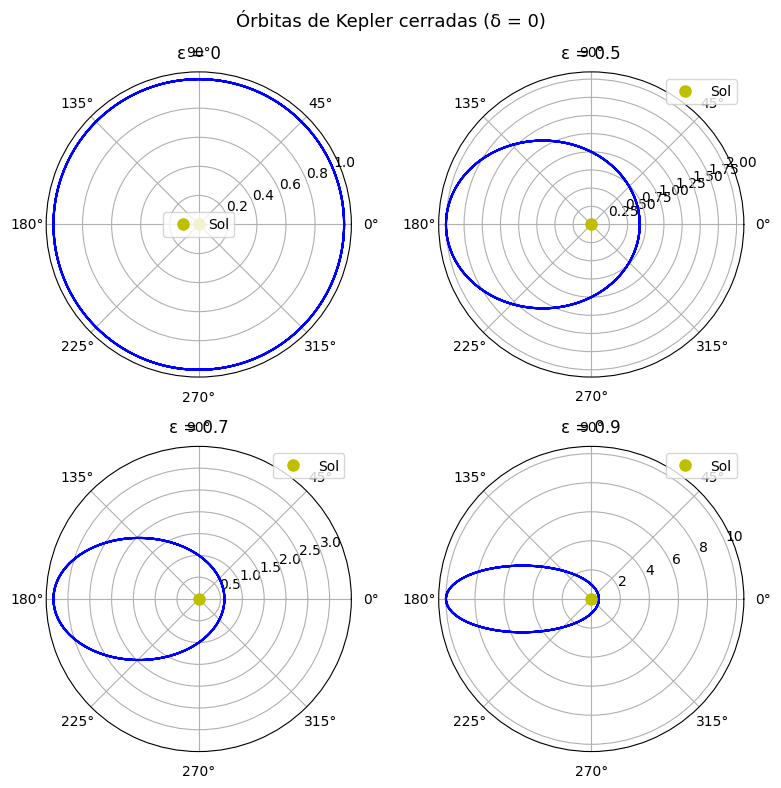

In [12]:
delta = 0
sol_1 = lambda f, y0 : solve_ivp(f, [ti,tf], y0, t_eval=lt, max_step=0.01)
grafico_orbitas(epsilons_cerradas, alpha, delta, sol_1)

## Órbitas abiertas con delta = 0

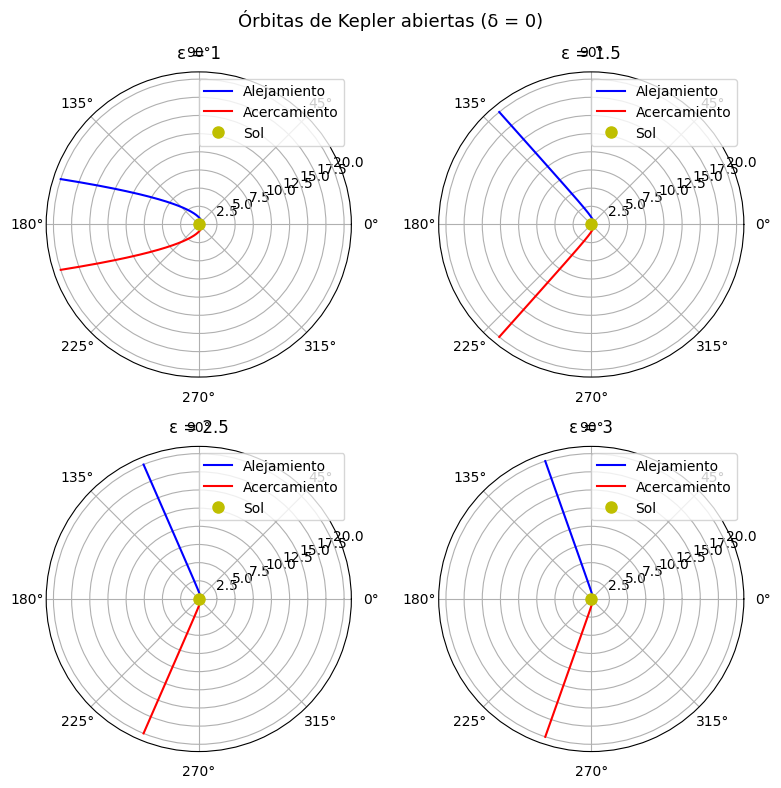

In [13]:
def evento_escape(theta, y):
    return y[0] - 0.05
evento_escape.terminal = True

sol_2 = lambda f, y0 : solve_ivp(f, [ti, tf], y0, events=evento_escape, max_step=0.01)
grafico_orbitas(epsilons_abiertas, alpha, delta, sol_2)

# **Ejercicio 3**

## Órbitas cerradas con delta = 0.05

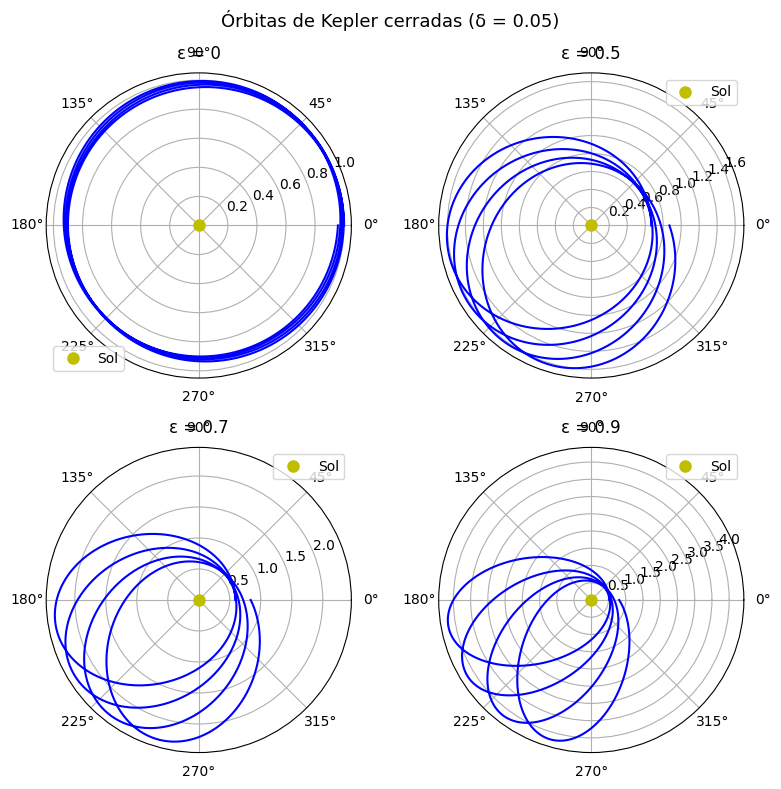

In [14]:
delta = 0.05

grafico_orbitas(epsilons_cerradas, alpha, delta, sol_1)

## Órbitas abiertas con delta = 0.05

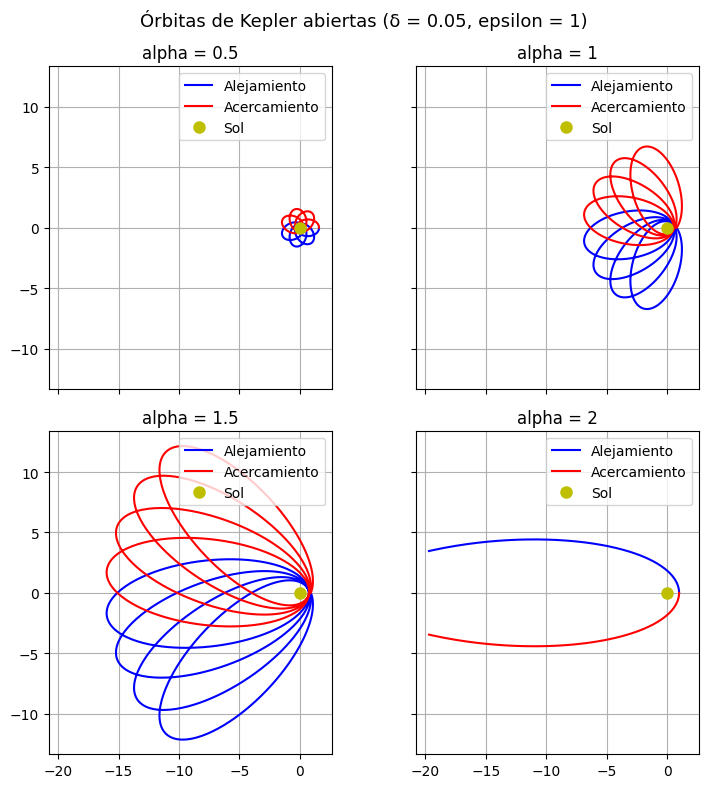

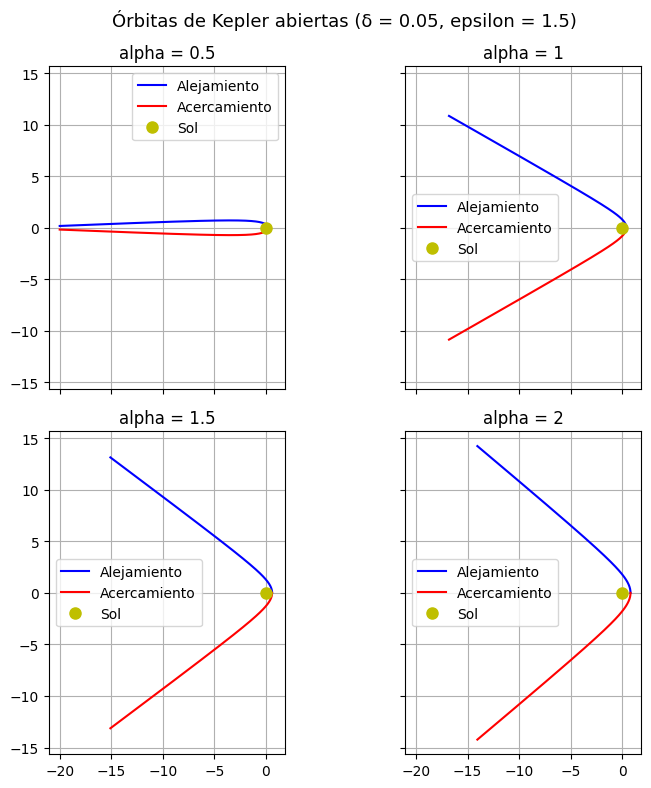

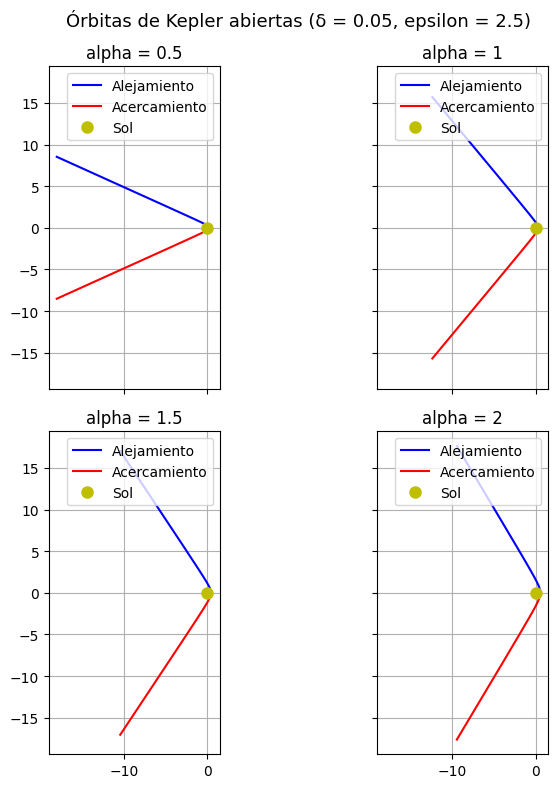

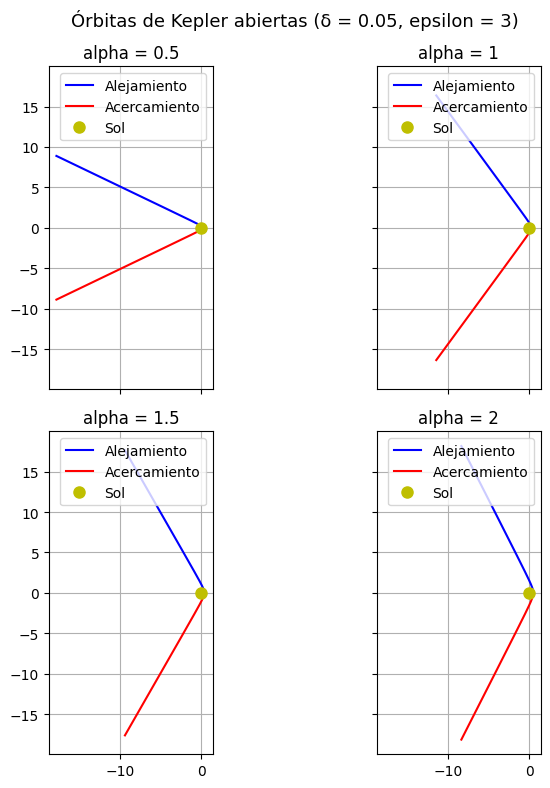

In [7]:
grafico_orbitas(epsilons_abiertas, alpha, delta, sol_2)